# CIFAR-10 Image Classification using Deep Learning

## Introduction

This notebook presents a deep learning approach for image classification using the CIFAR-10 dataset. The aim of the work was to build a model capable of classifying colour images into one of ten object categories. These categories include airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

CIFAR-10 was selected because it is a well-known computer vision dataset and is suitable for evaluating image classification models. It provides a realistic classification task while still being small enough to train within a student project environment.

The objective of this work was to design, train, and evaluate a Convolutional Neural Network (CNN) for this task. In addition to building the model, the notebook also examines preprocessing, data augmentation, performance evaluation, and possible model improvements.

This directly addresses the assignment requirement to select a public dataset, build an AI/deep learning model for image classification, explain preprocessing and augmentation, justify the model architecture, evaluate performance, and discuss improvements.

# CIFAR-10 Image Classification using Deep Learning

## Introduction

This notebook presents a deep learning approach for image classification using the CIFAR-10 dataset. The aim of the work was to build a model capable of classifying colour images into one of ten object categories. These categories include airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

CIFAR-10 was selected because it is a well-known computer vision dataset and is suitable for evaluating image classification models. It provides a realistic classification task while still being small enough to train within a student project environment.

The objective of this work was to design, train, and evaluate a Convolutional Neural Network (CNN) for this task. In addition to building the model, the notebook also examines preprocessing, data augmentation, performance evaluation, and possible model improvements.

This directly addresses the assignment requirement to select a public dataset, build an AI/deep learning model for image classification, explain preprocessing and augmentation, justify the model architecture, evaluate performance, and discuss improvements.

In [1]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Dataset tools
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Model building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

# Training utilities
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


In [3]:
# Class names for CIFAR-10
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Display dataset information
print("Number of training images:", x_train.shape[0])
print("Number of test images:", x_test.shape[0])
print("Image shape:", x_train.shape[1:])
print("Number of classes:", len(class_names))

Number of training images: 50000
Number of test images: 10000
Image shape: (32, 32, 3)
Number of classes: 10


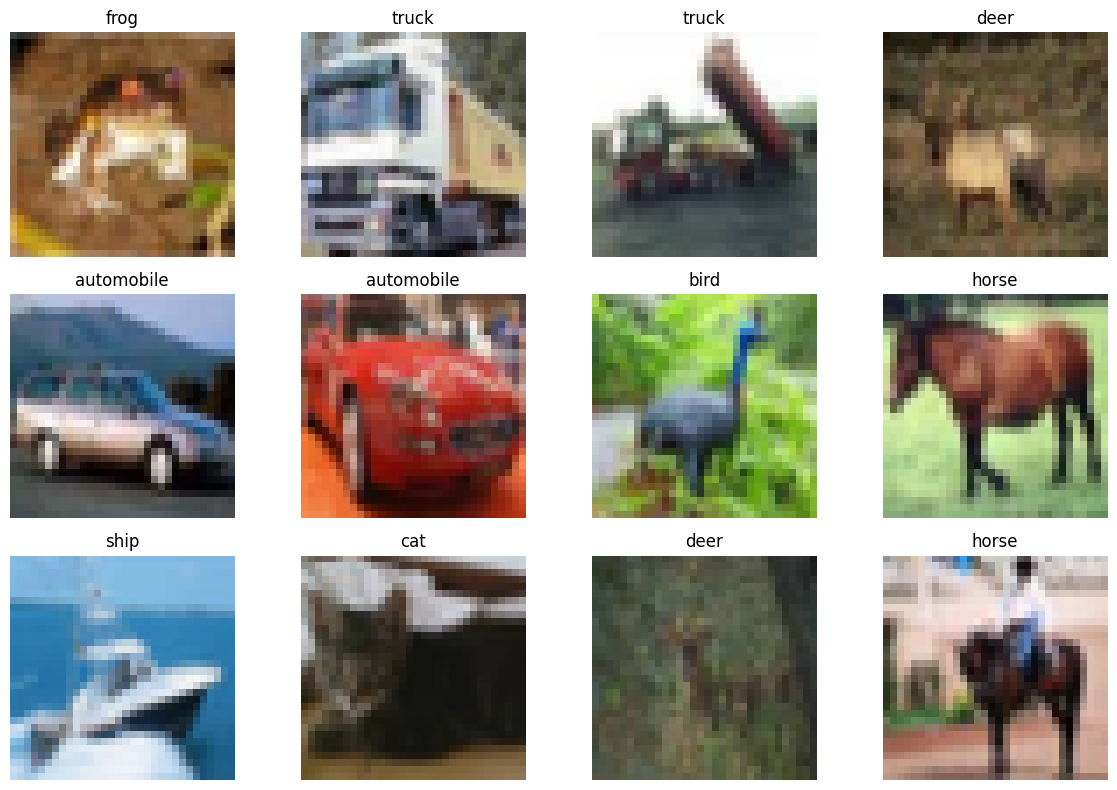

In [4]:
# Show sample images from the dataset
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Count how many images belong to each class in the training set
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{class_names[label]}: {count}")

airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


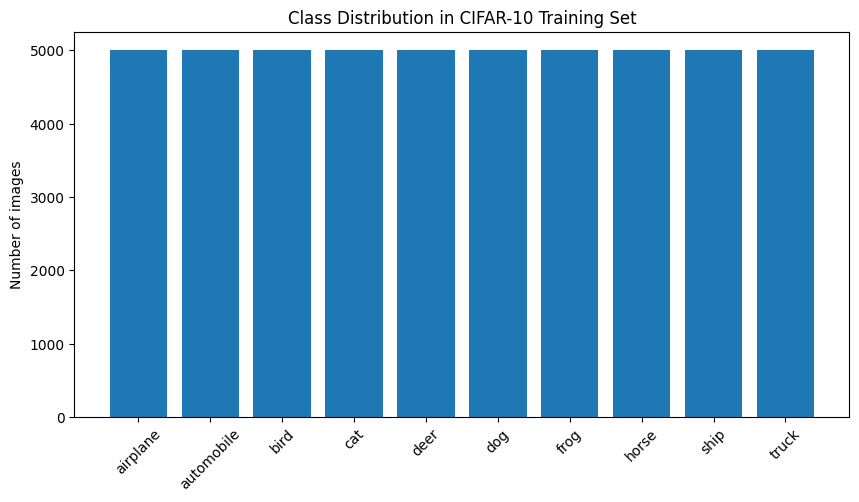

In [6]:
# Plot class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.ylabel("Number of images")
plt.title("Class Distribution in CIFAR-10 Training Set")
plt.show()

## Exploring the Dataset

Before training the model, the dataset was explored to better understand its structure and contents. This step was important because it helped confirm the number of images, the image dimensions, and the class labels included in the dataset.

A sample of training images was displayed to visually inspect the type of data being used. This made it possible to see the variation in objects, colours, and backgrounds across the dataset. It also confirmed that the task is challenging because the images are small and some classes are visually similar.

The class distribution was then checked to determine whether the dataset was balanced. CIFAR-10 contains an equal number of images in each category, which is useful because it reduces the risk of the model becoming biased toward one class more than another.

The exploratory analysis showed that CIFAR-10 is a balanced multiclass dataset, but the relatively low image resolution of 32 × 32 pixels makes feature extraction more difficult, increasing the importance of an effective CNN architecture.

## Data Preprocessing

Before training the model, several preprocessing steps were considered to improve image quality and prepare the data for deep learning. Preprocessing is important because it helps the model learn more effectively from the input data and can improve training stability and final performance.

For the final model, the main preprocessing steps used were normalization of pixel values and conversion of class labels into categorical format. These steps were chosen because they are standard and effective for CNN-based image classification.

Other preprocessing methods were also considered, including grayscale conversion, histogram equalisation, image reshaping, and Gaussian blurring. These methods can sometimes improve performance depending on the dataset, but they may also remove useful information. In the case of CIFAR-10, colour is an important feature for classification, so preserving the original RGB images was considered beneficial.

In [7]:
# Convert images to float32 and scale pixel values to the range [0, 1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

print("Normalized training data shape:", x_train_norm.shape)
print("Normalized test data shape:", x_test_norm.shape)
print("Pixel range after normalization:", x_train_norm.min(), "to", x_train_norm.max())

Normalized training data shape: (50000, 32, 32, 3)
Normalized test data shape: (10000, 32, 32, 3)
Pixel range after normalization: 0.0 to 1.0


### Normalisation

The original pixel values in CIFAR-10 range from 0 to 255. These values were scaled to the range [0, 1] by dividing each pixel by 255. This was done to make training more stable and to help the model learn more efficiently.

Normalisation is a standard preprocessing step in deep learning because very large input values can slow down optimisation and make convergence less reliable.

In [8]:
# Convert class labels to one-hot encoded format
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Original label example:", y_train[0])
print("One-hot encoded label example:", y_train_cat[0])

Original label example: [6]
One-hot encoded label example: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


### Label Encoding

The class labels were converted into categorical format using one-hot encoding. This means that each label was represented as a vector containing zeros and a single one at the position of the correct class.

This step was necessary because the model predicts probabilities across all ten classes, and categorical encoding matches the format expected by the output layer and loss function.

In [9]:
# Convert RGB images to grayscale using TensorFlow
x_train_gray = tf.image.rgb_to_grayscale(x_train).numpy()
x_test_gray = tf.image.rgb_to_grayscale(x_test).numpy()

# Normalize grayscale images
x_train_gray = x_train_gray.astype("float32") / 255.0
x_test_gray = x_test_gray.astype("float32") / 255.0

print("Grayscale training shape:", x_train_gray.shape)
print("Grayscale test shape:", x_test_gray.shape)

Grayscale training shape: (50000, 32, 32, 1)
Grayscale test shape: (10000, 32, 32, 1)


### Grayscale Conversion (Alternative)

Grayscale conversion was considered as an alternative preprocessing step. This reduces each image from three colour channels to a single intensity channel, which can simplify the input and reduce computational cost.

However, grayscale conversion was not selected as the main approach for the final model because CIFAR-10 is a colour-based dataset, and colour information may help distinguish between visually similar classes. For this reason, the final model retained RGB images.

In [10]:
import cv2

# Apply histogram equalisation to grayscale images
x_train_gray_uint8 = (x_train_gray.squeeze() * 255).astype("uint8")
x_test_gray_uint8 = (x_test_gray.squeeze() * 255).astype("uint8")

x_train_he = np.array([cv2.equalizeHist(img) for img in x_train_gray_uint8])
x_test_he = np.array([cv2.equalizeHist(img) for img in x_test_gray_uint8])

# Reshape to add channel dimension back
x_train_he = x_train_he[..., np.newaxis].astype("float32") / 255.0
x_test_he = x_test_he[..., np.newaxis].astype("float32") / 255.0

print("Histogram equalised training shape:", x_train_he.shape)

Histogram equalised training shape: (50000, 32, 32, 1)


### Histogram Equalisation (Alternative)

Histogram equalisation was considered to improve image contrast by spreading out the intensity values across the image. This can make certain edges or object boundaries more visible.

Although this method can sometimes improve image quality, it was not chosen as the main preprocessing method for the final CIFAR-10 model. The dataset contains natural images rather than low-contrast medical or grayscale images, so the benefits of histogram equalisation were less certain in this case.

In [11]:
# Apply Gaussian blur to normalized RGB images
x_train_blur = np.array([cv2.GaussianBlur(img, (3, 3), 0) for img in x_train_norm])
x_test_blur = np.array([cv2.GaussianBlur(img, (3, 3), 0) for img in x_test_norm])

print("Blurred training shape:", x_train_blur.shape)

Blurred training shape: (50000, 32, 32, 3)


### Gaussian Blurring (Alternative)

Gaussian blurring was considered as a way to reduce noise and smooth the images. This can sometimes help if the dataset contains unnecessary visual detail or noise.

However, because CIFAR-10 images are already very small, excessive smoothing may remove useful features such as edges and textures. For this reason, Gaussian blur was treated as an optional experimental preprocessing step rather than the main approach.

In [12]:
# Example: reshaping grayscale data for CNN input
x_train_gray_reshaped = x_train_gray.reshape(-1, 32, 32, 1)
x_test_gray_reshaped = x_test_gray.reshape(-1, 32, 32, 1)

print("Reshaped grayscale training data:", x_train_gray_reshaped.shape)

Reshaped grayscale training data: (50000, 32, 32, 1)


### Reshaping

Reshaping was required when preprocessing methods changed the image format, such as converting RGB images to grayscale. CNN models expect image data in a structured format that includes height, width, and channel dimensions.

For the final RGB model, additional reshaping was not required because the original CIFAR-10 format already matched the expected CNN input shape of 32 × 32 × 3.

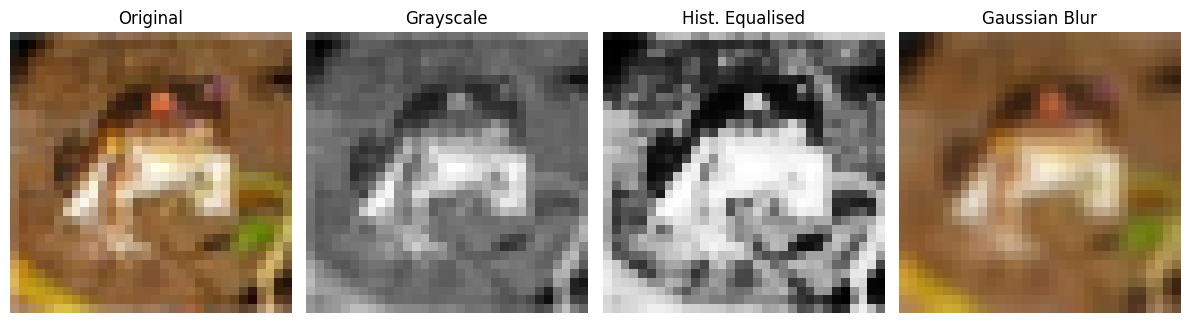

In [13]:
# Compare one original image with preprocessing alternatives
sample_index = 0

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(x_train[sample_index])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(x_train_gray[sample_index].squeeze(), cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(x_train_he[sample_index].squeeze(), cmap="gray")
plt.title("Hist. Equalised")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(x_train_blur[sample_index])
plt.title("Gaussian Blur")
plt.axis("off")

plt.tight_layout()
plt.show()

### Visual Comparison of Preprocessing Methods

A visual comparison was carried out to observe how different preprocessing methods changed the appearance of the images. This helped assess whether each method improved clarity or removed useful information.

The comparison showed that while grayscale conversion, histogram equalisation, and Gaussian blurring changed the visual appearance of the images, they also risked removing useful colour or texture information. As a result, the final model used normalized RGB images rather than heavily transformed versions.

For the final model, the preprocessing pipeline focused on preserving the original RGB image information while applying standard preparation steps for deep learning. Pixel values were normalised to the range [0,1] to improve training stability, and the class labels were converted to one-hot encoded vectors for multiclass classification. Additional preprocessing techniques such as grayscale conversion, histogram equalisation, and Gaussian blurring were considered, but these were not selected for the final model because they risked removing useful colour or texture information from the already small CIFAR-10 images.

## Data Augmentation

After preprocessing, data augmentation was applied to the training images. Data augmentation creates modified versions of existing images by making small random changes such as flipping, shifting, or rotating them. This helps the model learn from a wider variety of examples without needing new data.

Data augmentation was especially useful for CIFAR-10 because the images are small and the dataset, while standard, can still lead to overfitting if the model memorises the training examples. By exposing the model to slightly altered versions of the same objects, augmentation improves generalisation and helps the model perform better on unseen test data.

Only the training data was augmented. The validation and test data were kept unchanged so that model performance could be evaluated fairly on original images.|

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training images
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

# No augmentation for validation/test, only rescaling already done earlier
# Using the normalized data prepared before
train_generator = train_datagen.flow(
    x_train_norm,
    y_train_cat,
    batch_size=64,
    subset="training"
)

val_generator = train_datagen.flow(
    x_train_norm,
    y_train_cat,
    batch_size=64,
    subset="validation"
)

print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))

Training batches: 625
Validation batches: 157


### Selected Augmentation Strategy

The final augmentation strategy included small random rotations, horizontal flips, and width and height shifts. These transformations were chosen because they preserve the identity of the object while introducing realistic variation into the training data.

For example, an airplane or truck remains the same object even if it appears slightly shifted or mirrored. These transformations help the model become less sensitive to the exact position or orientation of the object within the image.

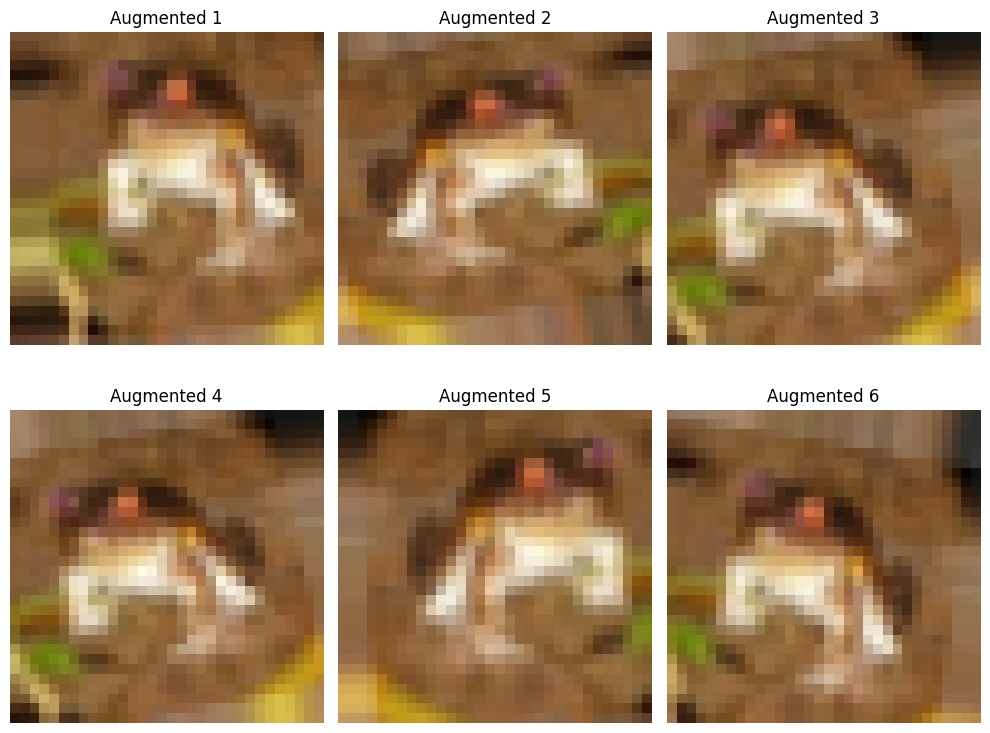

In [15]:
# Display augmented versions of one training image
sample_image = x_train_norm[0].reshape((1, 32, 32, 3))

plt.figure(figsize=(10, 8))

i = 0
for batch in train_datagen.flow(sample_image, batch_size=1):
    plt.subplot(2, 3, i + 1)
    plt.imshow(batch[0])
    plt.axis("off")
    plt.title(f"Augmented {i+1}")
    i += 1
    if i == 6:
        break

plt.tight_layout()
plt.show()

Data augmentation was applied only to the training data and not to the validation or test sets. This ensured that model evaluation was carried out on unchanged images, giving a fair measure of real performance.

## Building the Baseline CNN Model

A Convolutional Neural Network (CNN) was selected as the baseline model for this task. CNNs are well suited to image classification because they are designed to detect spatial patterns such as edges, textures, and shapes directly from image data.

Unlike a standard fully connected neural network, a CNN preserves the two-dimensional structure of the image and learns local visual features through convolutional filters. This makes it especially effective for computer vision problems such as CIFAR-10 classification.

The baseline model was designed with a small number of convolutional and pooling layers followed by dense layers for final classification. This provided a strong starting point that could later be improved through tuning and architectural changes.

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D

improved_model = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.35),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 batch_normalization_1 (Bat  (None, 32, 32, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                      

In [17]:
# Total number of trainable parameters
print("Total parameters:", improved_model.count_params())

Total parameters: 306602


### Baseline Architecture

The baseline CNN began with a convolutional layer containing 32 filters, followed by a max-pooling layer. This first stage was used to detect simple visual features such as edges and basic shapes while reducing the spatial size of the image.

A second convolutional layer with 64 filters was then added to learn more complex patterns. Another max-pooling layer reduced the feature map size further, helping to lower computational cost and reduce the risk of overfitting.

The output was then flattened into a one-dimensional vector and passed to a dense layer with 128 neurons. This dense layer combined the extracted features and prepared them for classification. A dropout layer was included before the final output layer to reduce overfitting by randomly deactivating some neurons during training.

The final layer used 10 output neurons with a softmax activation function, allowing the model to predict probabilities across the ten CIFAR-10 classes.

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

history_improved = improved_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=35,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/35


625/625 [==============================] - 99s 150ms/step - loss: 1.6016 - accuracy: 0.4155 - val_loss: 1.4585 - val_accuracy: 0.4864 - lr: 0.0010
Epoch 2/35
625/625 [==============================] - 96s 153ms/step - loss: 1.2451 - accuracy: 0.5555 - val_loss: 1.3125 - val_accuracy: 0.5397 - lr: 0.0010
Epoch 3/35
625/625 [==============================] - 72s 115ms/step - loss: 1.1030 - accuracy: 0.6112 - val_loss: 1.0688 - val_accuracy: 0.6273 - lr: 0.0010
Epoch 4/35
625/625 [==============================] - 28s 44ms/step - loss: 0.9952 - accuracy: 0.6518 - val_loss: 0.9512 - val_accuracy: 0.6621 - lr: 0.0010
Epoch 5/35
625/625 [==============================] - 24s 38ms/step - loss: 0.9179 - accuracy: 0.6829 - val_loss: 0.8394 - val_accuracy: 0.7036 - lr: 0.0010
Epoch 6/35
625/625 [==============================] - 25s 41ms/step - loss: 0.8606 - accuracy: 0.7038 - val_loss: 0.7896 - val_accuracy: 0.7279 - lr: 0.0010
Epoch 7/35
625/625 [==============================] -

## Training the Baseline Model

The baseline CNN was trained using the augmented training data and evaluated on the validation set during training. The Adam optimiser was selected because it is widely used in deep learning and performs well in practice for image classification tasks.

Categorical cross-entropy was used as the loss function because this is a multiclass classification problem with one-hot encoded labels. Accuracy was used as the main training metric to monitor how often the model predicted the correct class.

Early stopping was included to reduce overfitting. This method stops training when validation performance no longer improves, while restoring the best set of learned weights.

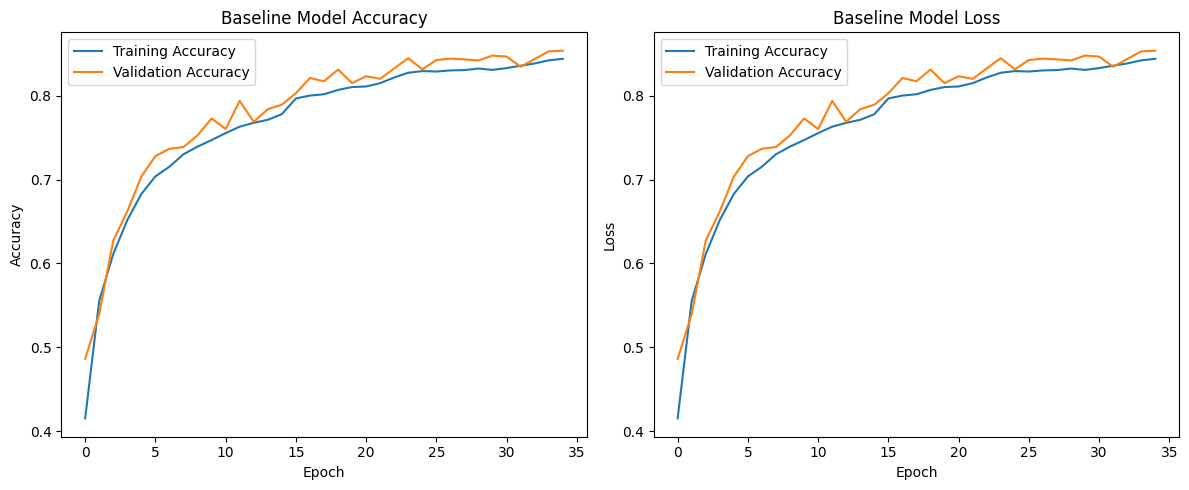

In [ ]:
# Plot training and validation accuracy/loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Training Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
plt.title('Improved Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Training Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.title('Improved Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Training Performance

The training history was plotted to examine how the model performed across epochs. Both accuracy and loss were monitored for the training and validation sets.

These plots are useful because they help identify whether the model is learning effectively, underfitting, or overfitting. If training accuracy continues to improve while validation accuracy stops improving or begins to decrease, this suggests that the model is starting to memorise the training data rather than generalising well.

Similarly, if validation loss begins to rise while training loss keeps falling, this is another sign of overfitting. Monitoring these trends helps assess whether the chosen architecture and training strategy are appropriate.

In [20]:
test_loss, test_accuracy = improved_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print("Improved Test Loss:", test_loss)
print("Improved Test Accuracy:", test_accuracy)

Improved Test Loss: 0.49083295464515686
Improved Test Accuracy: 0.8374999761581421


## Test Set Evaluation

After training, the model was evaluated on the test set. This is an important step because the test set contains unseen data that was not used during training or validation.

Test accuracy provides an overall measure of how well the model generalises to new images. Test loss gives additional information about how confident and well-calibrated the predictions are. Evaluating on unseen data is necessary to judge the true performance of the model.

In [21]:
# Generate predictions on the test set
y_pred_probs = improved_model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

313/313 [==============================] - 2s 7ms/step


In [22]:
# Print classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.87      0.86      0.87      1000
  automobile       0.92      0.94      0.93      1000
        bird       0.86      0.73      0.79      1000
         cat       0.83      0.57      0.68      1000
        deer       0.82      0.79      0.80      1000
         dog       0.83      0.75      0.79      1000
        frog       0.67      0.97      0.79      1000
       horse       0.86      0.90      0.88      1000
        ship       0.94      0.91      0.92      1000
       truck       0.84      0.95      0.89      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



## Confusion Matrix

A confusion matrix was used to visualise how predictions were distributed across the ten classes. This provides a detailed view of which categories were classified correctly and which were commonly confused.

The diagonal values represent correct classifications, while off-diagonal values show mistakes. This is particularly useful in CIFAR-10 because some categories are visually similar, making confusion more likely.

By analysing the confusion matrix, it becomes possible to identify which classes are easiest for the model and which ones may require further improvement through architectural changes or stronger training strategies.

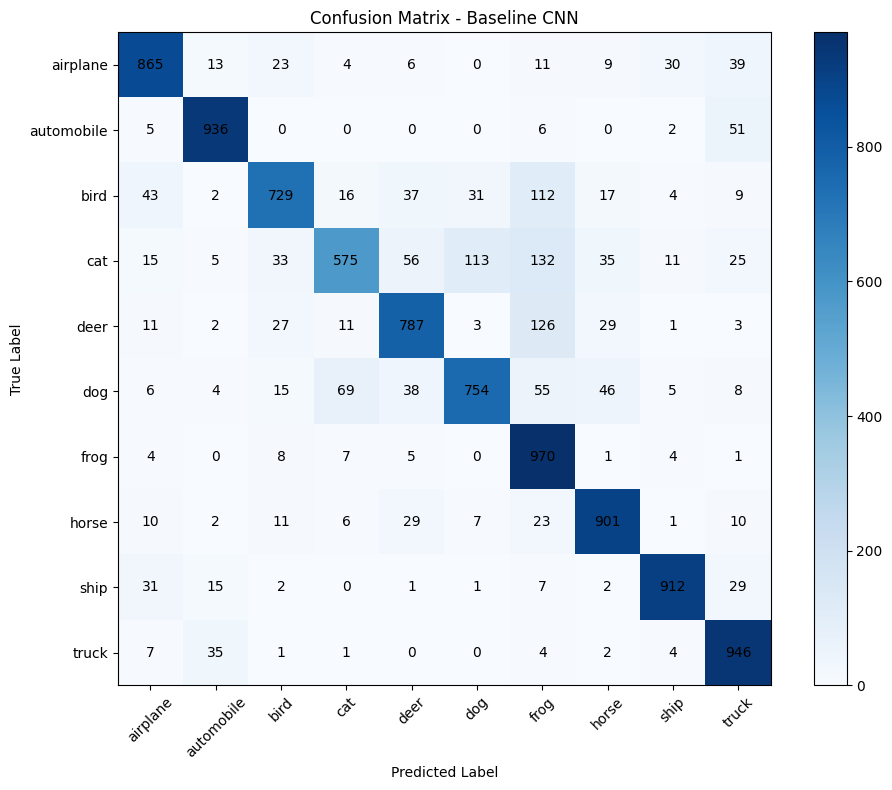

In [23]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - Baseline CNN")
plt.colorbar()
plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=45)
plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add values inside the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

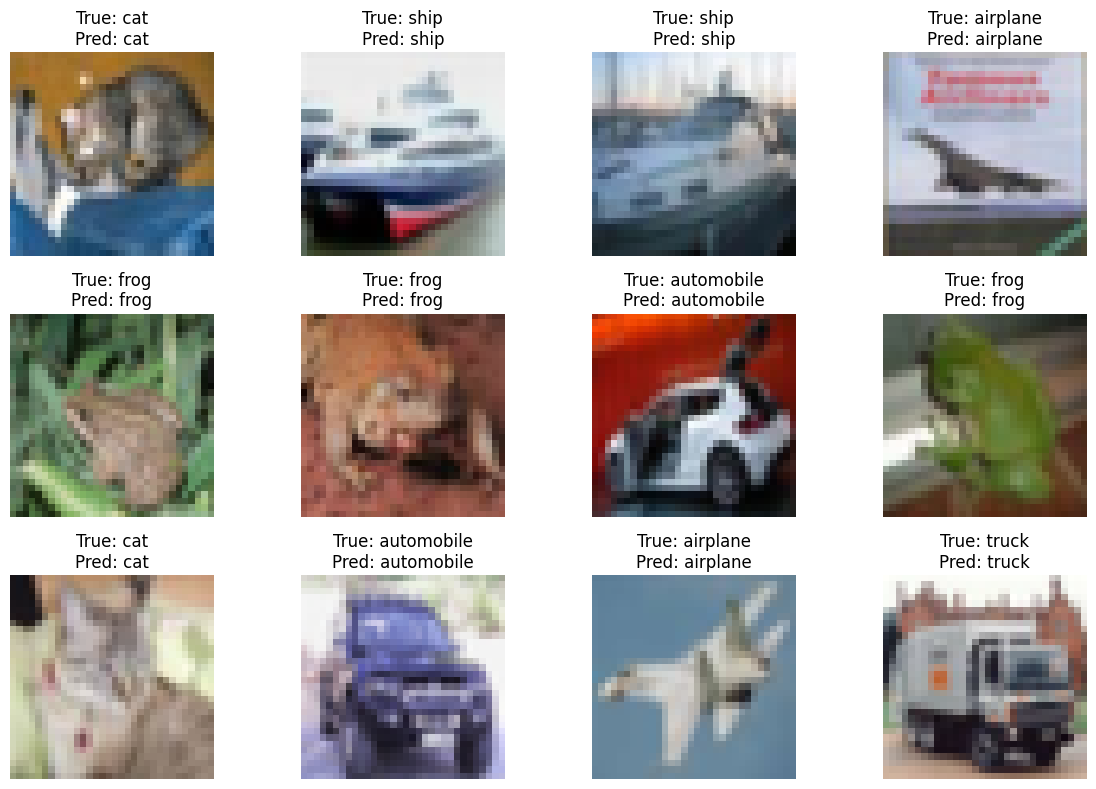

In [24]:
# Display sample predictions
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i])
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

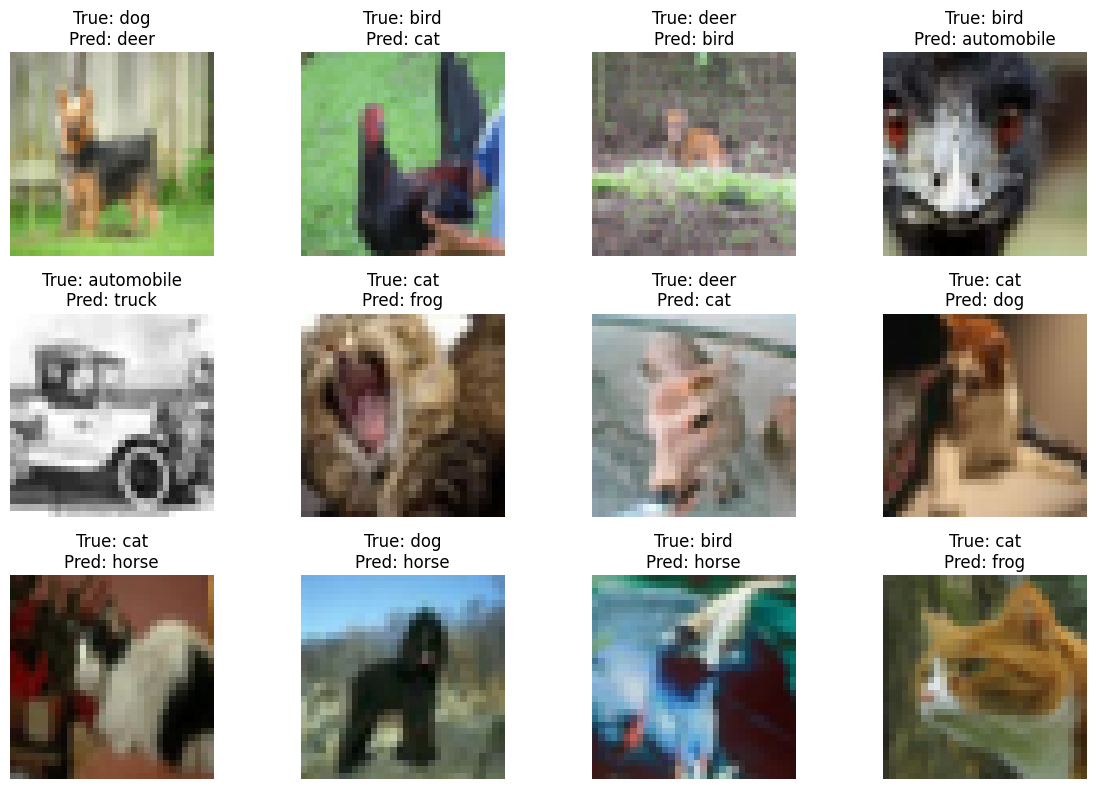

In [25]:
# Show some misclassified images
misclassified = np.where(y_true != y_pred)[0]

plt.figure(figsize=(12, 8))

for i, idx in enumerate(misclassified[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Example Predictions

A sample of predictions was displayed to better understand the model’s behaviour. This included both correctly classified and misclassified images.

Viewing individual predictions is useful because it gives a more practical sense of model performance than numerical scores alone. Misclassified examples can reveal whether errors are caused by low image quality, visual similarity between classes, or difficulty in learning certain object features.

The baseline CNN achieved reasonable performance on the CIFAR-10 dataset, showing that it was able to learn meaningful visual patterns from the images. The training curves helped assess whether the model was learning effectively, while the classification report and confusion matrix provided a more detailed evaluation across all classes. Although the baseline model performed well overall, some class confusion was expected because CIFAR-10 contains small low-resolution images and several visually similar categories.